<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Mini_Projet_wekk2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Chargement et prétraitement

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_excel('SampleSuperstore.xls')

# Aperçu
df.head()

# Informations générales
df.info()

# Valeurs manquantes
df.isnull().sum()

# Doublons
df.duplicated().sum()

# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

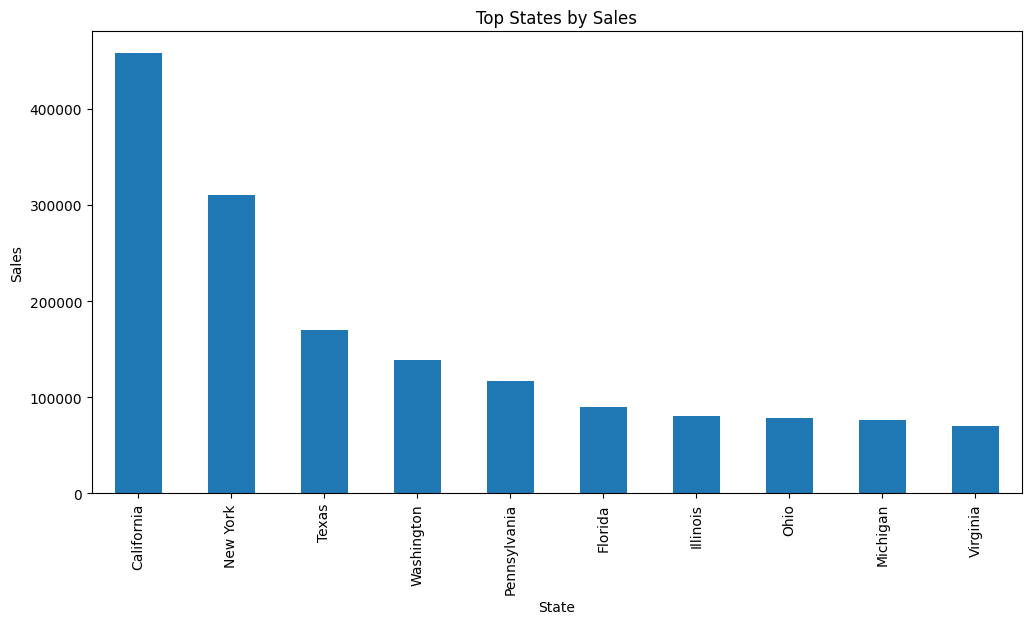

In [8]:
#États avec le plus de ventes

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_sales.head(10).plot(kind='bar')
plt.title('Top States by Sales')
plt.ylabel('Sales')
plt.show()

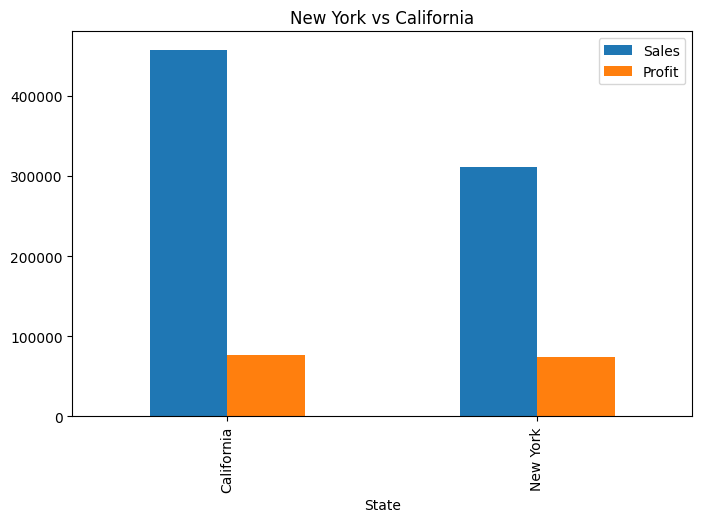

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


In [9]:
#Comparaison New York vs California

ny_ca = df[df['State'].isin(['New York','California'])]

comparison = ny_ca.groupby('State')[['Sales','Profit']].sum()

comparison.plot(kind='bar', figsize=(8,5))
plt.title('New York vs California')
plt.show()

print(comparison)

In [10]:
#Client exceptionnel à New York

ny = df[df['State']=='New York']

top_customer_ny = ny.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

top_customer_ny.head(10)

,Sales
Customer Name,
Tom Ashbrook,13723.498
Peter Fuller,7678.228
Seth Vernon,7359.918
Tom Boeckenhauer,6999.960
Greg Tran,6712.744
Todd Sumrall,6492.314
Karen Daniels,6241.282
Keith Dawkins,5854.194
Luke Weiss,5048.186


In [11]:
#Différences de rentabilité entre États

state_profitability = df.groupby('State')[['Sales','Profit']].sum()

state_profitability['Profit_Margin'] = (
    state_profitability['Profit'] /
    state_profitability['Sales']
)

state_profitability.sort_values(
    'Profit_Margin',
    ascending=False
).head()

,Sales,Profit,Profit_Margin
State,,,
District of Columbia,2865.020,1059.5893,0.369837
Delaware,27451.069,9977.3748,0.363460
Minnesota,29863.150,10823.1874,0.362426
Maine,1270.530,454.4862,0.357714
Arkansas,11678.130,4008.6871,0.343264


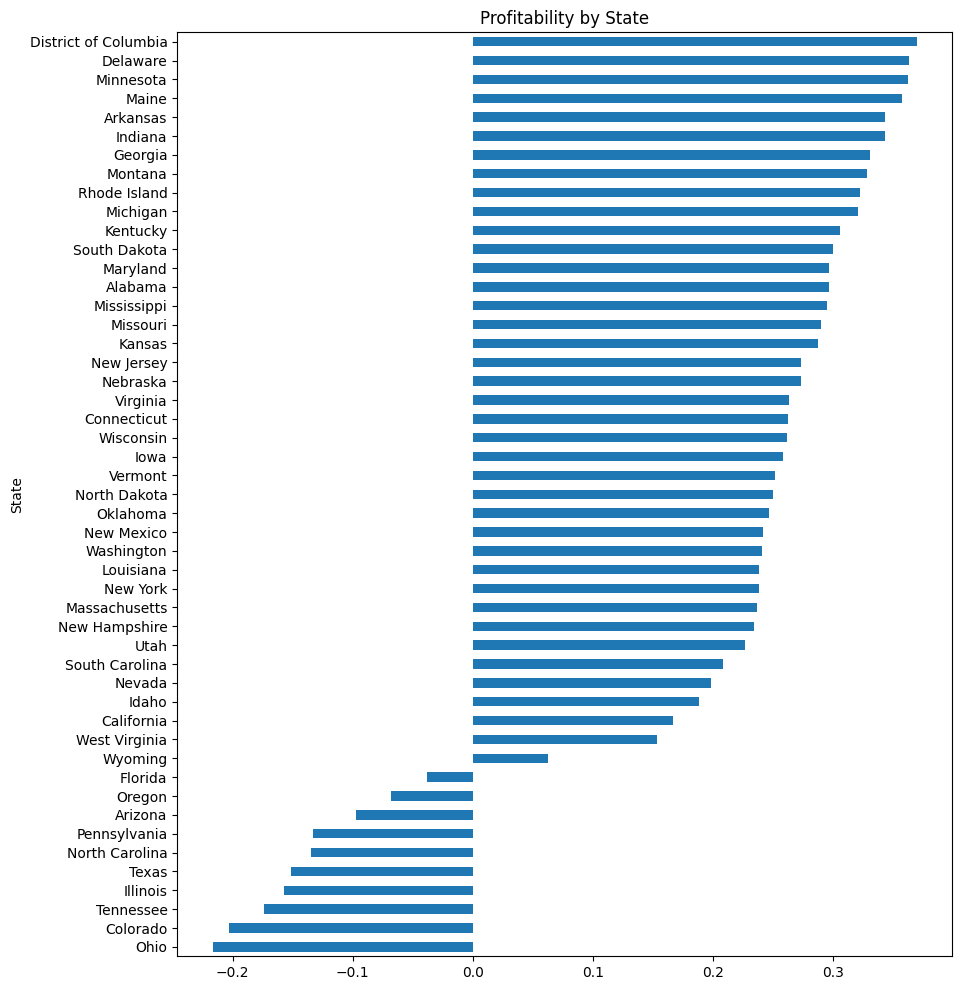

In [12]:
state_profitability['Profit_Margin'].sort_values().plot(
    kind='barh',
    figsize=(10,12)
)

plt.title('Profitability by State')
plt.show()

In [13]:
#Pareto sur le profit (80/20)

customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)

cum_profit = customer_profit.cumsum()

cum_profit_pct = (
    cum_profit /
    customer_profit.sum()
) * 100

In [14]:
#Nombre de clients nécessaires pour atteindre 80 %

customers_80 = (
    cum_profit_pct <= 80
).sum()

total_customers = len(customer_profit)

percentage = (
    customers_80 /
    total_customers
) * 100

print(percentage)

19.167717528373267


L'analyse montre qu'environ 19,17 % des clients génèrent 80 % des ventes totales. Ce résultat est très proche de la règle 80/20 de Pareto.

On peut donc conclure que le principe de Pareto s'applique aux clients et aux ventes dans ce jeu de données. Une minorité de clients contribue à la majorité du chiffre d'affaires et mérite une attention particulière dans les stratégies marketing et de fidélisation.

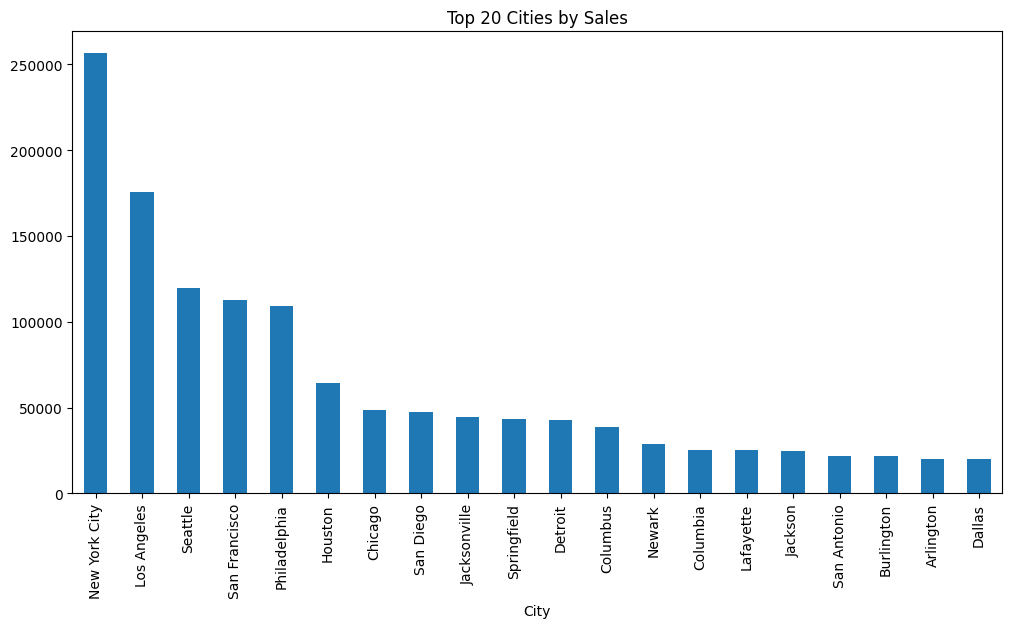

In [15]:
#Top 20 villes par ventes

top20_sales_city = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_sales_city.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 20 Cities by Sales')
plt.show()

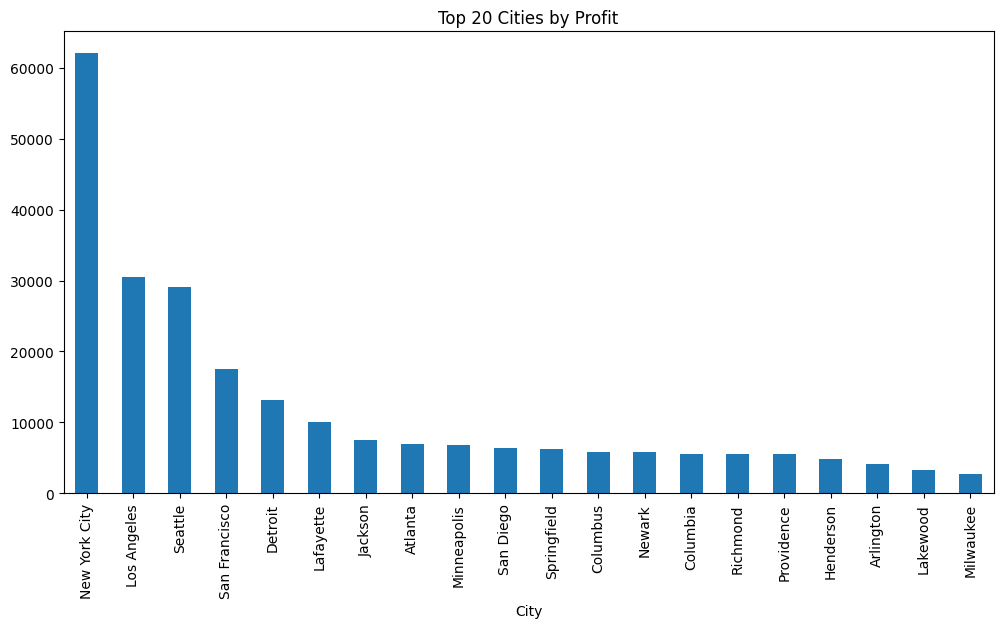

In [16]:
#Top 20 villes par profit

top20_profit_city = (
    df.groupby('City')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_profit_city.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 20 Cities by Profit')
plt.show()

In [17]:
#Comparer les deux listes

set(top20_sales_city.index) - set(top20_profit_city.index)

{'Burlington',
 'Chicago',
 'Dallas',
 'Houston',
 'Jacksonville',
 'Philadelphia',
 'San Antonio'}

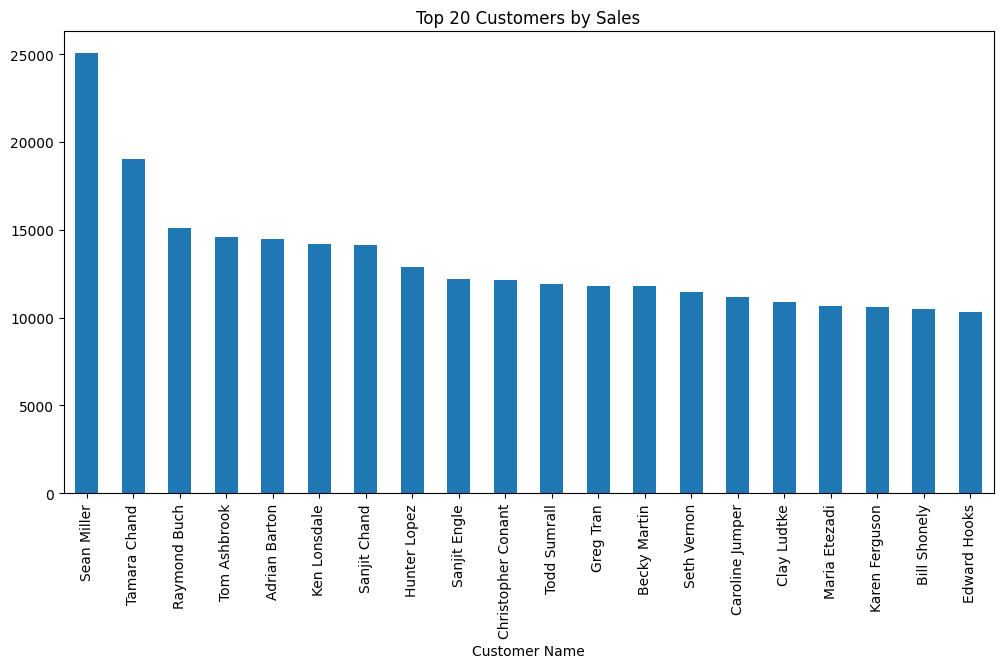

In [18]:
#Top 20 clients par ventes

top20_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_customers.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 20 Customers by Sales')
plt.show()

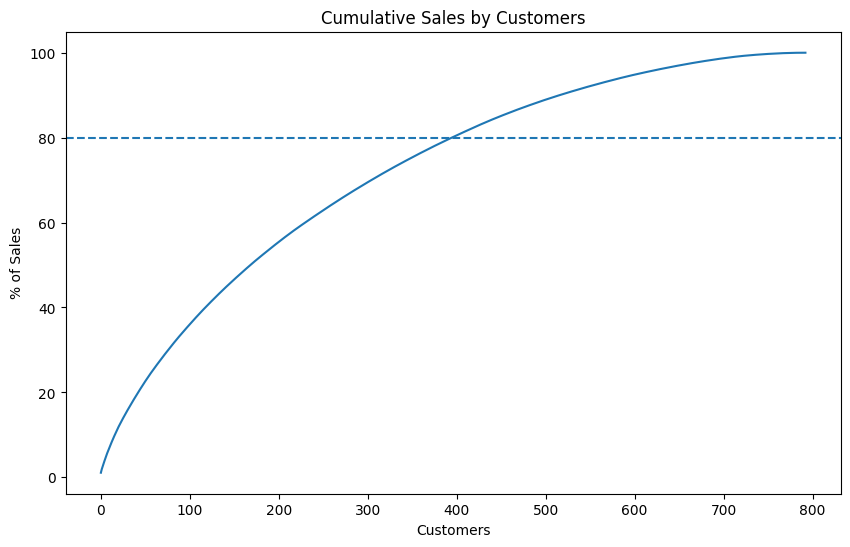

In [19]:
#Courbe cumulative des ventes (Pareto)

customer_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

cum_sales_pct = (
    customer_sales.cumsum()
    / customer_sales.sum()
) * 100

plt.figure(figsize=(10,6))
plt.plot(cum_sales_pct.values)
plt.axhline(80, linestyle='--')
plt.title('Cumulative Sales by Customers')
plt.ylabel('% of Sales')
plt.xlabel('Customers')
plt.show()

In [20]:
#Calcul

customers_80_sales = (
    cum_sales_pct <= 80
).sum()

percentage_sales = (
    customers_80_sales /
    len(customer_sales)
) * 100

print(percentage_sales)

49.810844892812106


**CONCLUSION**

En conclusion, les décisions qu'il faut prendre consisteront à:
*Prioriser les États générant le plus de profit.
*Renforcer les campagnes marketing dans les villes du Top 20.
*Fidéliser les clients contribuant fortement aux ventes et aux profits.
*Réduire les investissements dans les zones à forte vente mais faible rentabilité.
*Mettre en place des programmes VIP pour les clients identifiés par l'analyse Pareto.